# <span style="color:darkblue"> **Project 2: Social Networks Jornal Analysis**  </span>


# <span style="color:purple"> **Introduction**  </span>

<font size = "4">

This project analyzes research articles from the *Social Networks* journal.  
Building upon Project 1, I refined the data cleaning process and focused on three goals:

- **Diagnose missing data** and verify patterns across article types.  
- **Visualize text-based features**, such as title words and keywords, to uncover research themes.  
- **Explore collaboration patterns** among authors to identify the journal’s most active contributors.


# <span style="color:purple"> **Data Overview and Cleaning**  </span>

<font size = "4">

In this sectiom, I import the data, check for missing values, remove duplicates, and split columns to extract date information. 

- I keep only research articles to focus on empirical studies;
- Drop duplicate entries (some articles appeared in different issues);
- Extract publication month and year for trend analysis.

In [2]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import itertools

/Users/zhangxiaobei/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
#Load data
networks = pd.read_csv("/Users/zhangxiaobei/Documents/GitHub/datasci530fall2025/project1/social_networks_articles.csv")
networks.head()

,Volume,Date,Article,Authors,Article_URL,Type,Keywords
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,"Jennifer Watling Neal, Zachary P. Neal",https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-..."
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,"Emily Kruidhof, Rense Corten, Lea Ellwardt, Ra...",https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ..."
2,Volume 84,In progress (January 2026),Networked inequality: The role of changes in n...,"Alejandro Plaza, Guillermo Beck, Julio Iturra-...",https://www.sciencedirect.com/science/article/...,Research article,"Personal networks, Social influence, Social cl..."
3,Volume 84,In progress (January 2026),Robust network scale-up method estimators,"Sergio Díaz-Aranda, Juan Marcos Ramírez, Jose ...",https://www.sciencedirect.com/science/article/...,Research article,"Network scale-up method, Aggregated relational..."
4,Volume 84,In progress (January 2026),Can an eye for an eye turn the whole world san...,"Khrystyna Holynska, Renato Corbetta, Carter T....",https://www.sciencedirect.com/science/article/...,Research article,"International sanctions, Social network analys..."


In [4]:
#Display types of articles
networks["Type"].value_counts()

Type
Research article       361
Editorial board         21
Erratum                  5
Editorial                4
Short communication      1
Name: count, dtype: int64

In [5]:
# Subset dataset only contains research articles
research = networks.query("Type == 'Research article'").copy()
print(research.nunique())
print(research.shape)

Volume          22
Date            22
Article        360
Authors        345
Article_URL    361
Type             1
Keywords       145
dtype: int64
(361, 7)


In [6]:
# Missing value
research.isna().sum()

Volume           0
Date             0
Article          0
Authors          0
Article_URL      0
Type             0
Keywords       209
dtype: int64

<font size = "4">

I examined missing values and found that, among the 361 observations, 209 entries lacked keyword information.
After manually checking five of these articles on the journal’s website, I observed that they were inaccessible due to restricted access. Therefore, the missing keywords cannot be fully attributed to the article lacking keywords, but may also result from access limitations during data collection.

In [7]:
# Find Duplicated Article
dup_titles = research[research.duplicated(subset='Article', keep = False)]
dup_titles


,Volume,Date,Article,Authors,Article_URL,Type,Keywords
118,Volume 77,Pages 1-196 (May 2024),Network ecology: Tie fitness in social context(s),"Malte Doehne, Daniel A. McFarland, James Moody",https://www.sciencedirect.com/science/article/...,Research article,"Network ecology, Tie fitness, Relational niche..."
134,Volume 76,Pages 1-230 (January 2024),Network ecology: Tie fitness in social context(s),"Malte Doehne, Daniel A. McFarland, James Moody",https://www.sciencedirect.com/science/article/...,Research article,"Network ecology, Tie fitness, Relational niche..."


<font size = "4">

**Duplicate Verification**

To identify duplicates, I used the article title as the distinct identifier and found that *Network ecology: Tie fitness in social context(s)* appeared twice in the dataset.
To verify whether this duplication was due to a web scraping error, I manually checked the journal’s website. The same article indeed appeared in both Volume 76 and Volume 77 with identical content. Therefore, I dropped one of the duplicate entries.

In [8]:
#Drop duplicates
research = research.drop_duplicates(subset='Article')

In [9]:
# Split column Date
research[["page", "date"]] = (research["Date"].str.extract(r"^(.*?)\s*\((.*?)\)$"))
research["date"] = pd.to_datetime(research["date"], format="%B %Y").dt.strftime("%Y-%m")
research.head()


,Volume,Date,Article,Authors,Article_URL,Type,Keywords,page,date
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,"Jennifer Watling Neal, Zachary P. Neal",https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,"Emily Kruidhof, Rense Corten, Lea Ellwardt, Ra...",https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
2,Volume 84,In progress (January 2026),Networked inequality: The role of changes in n...,"Alejandro Plaza, Guillermo Beck, Julio Iturra-...",https://www.sciencedirect.com/science/article/...,Research article,"Personal networks, Social influence, Social cl...",In progress,2026-01
3,Volume 84,In progress (January 2026),Robust network scale-up method estimators,"Sergio Díaz-Aranda, Juan Marcos Ramírez, Jose ...",https://www.sciencedirect.com/science/article/...,Research article,"Network scale-up method, Aggregated relational...",In progress,2026-01
4,Volume 84,In progress (January 2026),Can an eye for an eye turn the whole world san...,"Khrystyna Holynska, Renato Corbetta, Carter T....",https://www.sciencedirect.com/science/article/...,Research article,"International sanctions, Social network analys...",In progress,2026-01


# <span style="color:purple"> **Part 1: Text Analysis of Article Titles**  </span>

<font size = "4">

To identify major research themes in the past five years, I visualize the most common words appearing in article titles using a WordCloud.


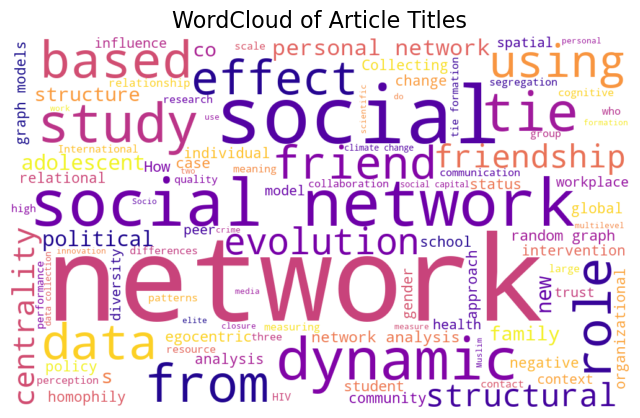

In [10]:
# Combine all article titles into a string
text = "".join(research["Article"])

# Create a WordCloud object
titlecloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="plasma",
    max_words=100,
    stopwords={"the", "and", "of", "to", "in", "for", "a", "an", "on", "among", "is", "with", "between", "or", "as", "across", "are"} 
).generate(text)

# Display the WordCloud
plt.figure(figsize=(8,6))
plt.imshow(titlecloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Article Titles", fontsize=16)
plt.show()

<font size = "4">

**Finding**

After removing common stopwords, the WordCloud reveals the 100 most frequent words in article titles.

Terms such as *network, social, dynamic, friend, study, evolution, structure, tie, effect, and centrality* highlight major themes in social network analysis.These words reflect the journal’s emphasis on network structures, dynamic processes, and interpersonal ties such as friendship and family relations.

To gain deeper insight into the thematic directions of the journal, the next section examines keyword patterns.

# <span style="color:purple"> **Part 2: Keyword Trends Over Time**  </span>

<font size = "4">

This section identified the most common keywords and tracked how their prominence evolved over time.

- Tabulate the top 22 most frequent keywords;
- Plot the top 5 frequent keywords to illustrate how their usage has evolved over the past five years.


**Coding rationale**:

1. Keyword frequency count

- The `"Keywords"` column contained terms separated by commas, so each row was split into individual keywords using `.str.split(",")` and expanded with `.explode()`.
- I used `.value_counts()` to compute keyword frequencies and then selected the top 22 keywords rather than 20, since several keywords have with the same frequency (4 occurrences).

2. Keywords trend visualization

- I chose the top five keywords to plot the time trend. 
- The `"date"` column was converted to a four-digit `"year"` variable to allow grouping by publication year. 
- I used the `.pivot()` transformation to reshap the dataset (years as rows, keywords as columns) to build the stacked bar chart.


In [11]:
# Split keywords column
keywords = (research["Keywords"]
            .dropna()
            .str.split(",")
            .explode()
            .str.strip())

# Compute keywords frequency
keywords.value_counts()

Keywords
Social network analysis             13
Stochastic actor-oriented models     8
Social networks                      8
Homophily                            7
Personal networks                    7
                                    ..
Correlation                          1
Threshold graphs                     1
Cognitive Social Structures          1
Network motifs                       1
Exact statistics                     1
Name: count, Length: 674, dtype: int64

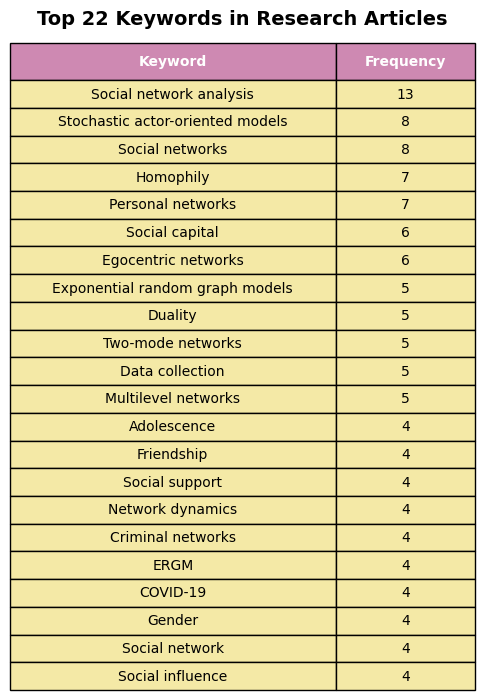

In [12]:
# Extract top 22 frequent keywords
top22 = keywords.value_counts().head(22).reset_index()
top22.columns = ["Keyword", "Frequency"]

# Set figure size
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Creat table data
table_data = [["Keyword", "Frequency"]] + top22.values.tolist()

# Draw table
table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    colWidths=[0.7, 0.3]
)

# Table background colors
for (row, col), cell in table.get_celld().items():
    if row == 0: 
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#CE89B2")
        cell.set_height(0.08)
    else:
        cell.set_facecolor("#F4E9A6")
        cell.set_height(0.06)

# Table title
plt.title("Top 22 Keywords in Research Articles", fontsize=14, pad=80, weight='bold')
plt.show()

<font size = "4">

**Finding**

The keywords frequency table showed that in addition to words that frequently appear in article titles, methodological terms such as “stochastic actor-oriented models”, “exponential random graph models”, and “ERGM” appear frequently. These terms indicate the popularity of specific modeling approaches in Social Networks research.

Another recurring theme concerned network structures and features, including “homophily”, “duality”, “two-mode networks”, “egocentric networks”, and “multilevel networks”. These keywords suggested research interest in understanding types of social network.

In [13]:
# Top5 keywords
top5 = keywords.value_counts().head(5).index.tolist()

# Subset date from research
keyword_data = research.dropna(subset=["Keywords"]).copy()
keyword_data["Keywords"] = keyword_data["Keywords"].str.split(",")
keyword_data = keyword_data.explode("Keywords")
keyword_data["Keywords"] = keyword_data["Keywords"].str.strip()

#Only reserve rows with top 5 keywords
keyword5 = keyword_data[keyword_data["Keywords"].isin(top5)].copy()
keyword5["year"] = keyword5["date"].str[:4]

#frequency by year
keyword_trend = (
    keyword5.groupby(["year", "Keywords"])
    .size()
    .reset_index(name="count")
)

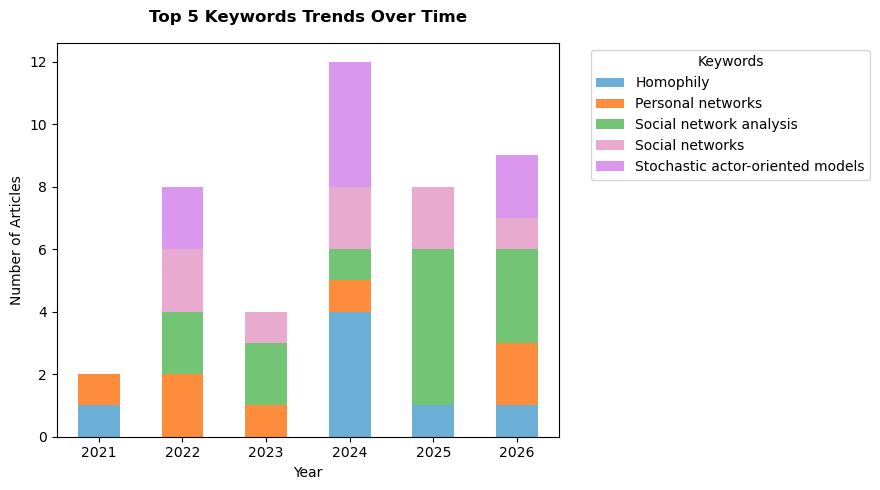

In [14]:
# Convert the data table
# Keywords as columns, years as index
pivot = keyword_trend.pivot(index="year", columns="Keywords", values="count").fillna(0)
pivot = pivot.sort_index()
pivot

# Draw stacked bar chart
pivot.plot(
    kind="bar",
    stacked=True,
    color=["#6BAED6", "#FD8D3C", "#74C476", "#E8ABCF", "#DB97EE"], 
    figsize = (9, 5)
)
plt.title("Top 5 Keywords Trends Over Time", weight="bold", pad=15)
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.legend(title="Keywords", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<font size = "4">

**Finding**

In the stacked bar chart, I selected the top 5 keywords to illustrate the prominence of research themes in Social Networks across recent years. “Social network analysis” and “social networks” appear consistently over time, which is intuitive. ““Stochastic actor-oriented models” gained noticeable popularity in 2024, reflecting a growing emphasis on computational modeling approaches. Meanwhile, “homophily” and “personal networks” show modest but stable representation, suggesting a sustained interest in the mechanisms underlying network formation.

# <span style="color:purple"> **Part 3: Author Collaboration and Publications**  </span>

<font size="4">

In this section, I examined collaboration and publication productivity among authors in *Social Networks*. I constructed coauthorship pairs from multi-author articles, identify the most widely connected authors by their number of coauthors, and compare them with the most productive authors. 

I created two horizontal bar charts to visualize:

The first shows the Top 20 authors with the largest number of coauthors.

The second shows the Top 20 authors with the most publications.

In the chart Top 20 Authors by Publication Numbers, authors who also appeared in top coauthor list were colored pink to visualize overlap between high productivity and high collaboration, while others were colored light blue.

**Coding rationale**
1. Generate coauthor pairs
- I used `itertools.combinations(authors, 2)` to generate all unordered author pairs (A–B, A–C, B–C, etc.), ensuring no duplicated reverse pairs such as (A, B) and (B, A).
- I then used `pd.concact().` to duplicate the coauthor pairs, generating "B → A" for each "A → B", to calculate the number of collaborators each author have.
- I then used `.groupby("Author")["Coauthor"].nunique()` to count the number of distinct coauthors per author.

2. Measure productivity
- I exploded the "Authors" column again so that each author–article combination occupied one row.  .
- I used `.value_counts()` to calculated the total number of publications by author.



In [15]:
# convert Authors column to list
coauthor = research.copy()
coauthor["Authors"] = coauthor["Authors"].str.split(",")
coauthor["Authors"] = coauthor["Authors"].apply(lambda lst: [a.strip() for a in lst])

In [16]:
# generate coauthor pairs
pairs = []
for authors in coauthor["Authors"]:
    for a, b in itertools.combinations(authors, 2):
        pair = tuple(sorted([a, b]))
        pairs.append(pair)

# Convert to dataframe
coauthor_pairs = pd.DataFrame(pairs, columns=["Author1", "Author2"])

# Convert pairs table into a directed table of Author-Coauthor
author_co = pd.concat([
    coauthor_pairs.rename(columns={"Author1": "Author", "Author2": "Coauthor"}),
    coauthor_pairs.rename(columns={"Author2": "Author", "Author1": "Coauthor"})
])

#Count numbers of coauthors
coauthor_count = (
    author_co.groupby("Author")["Coauthor"]
    .nunique()
    .reset_index(name="Num_Coauthors")
    .sort_values("Num_Coauthors", ascending=False)
)

coauthor20 = coauthor_count.head(20)

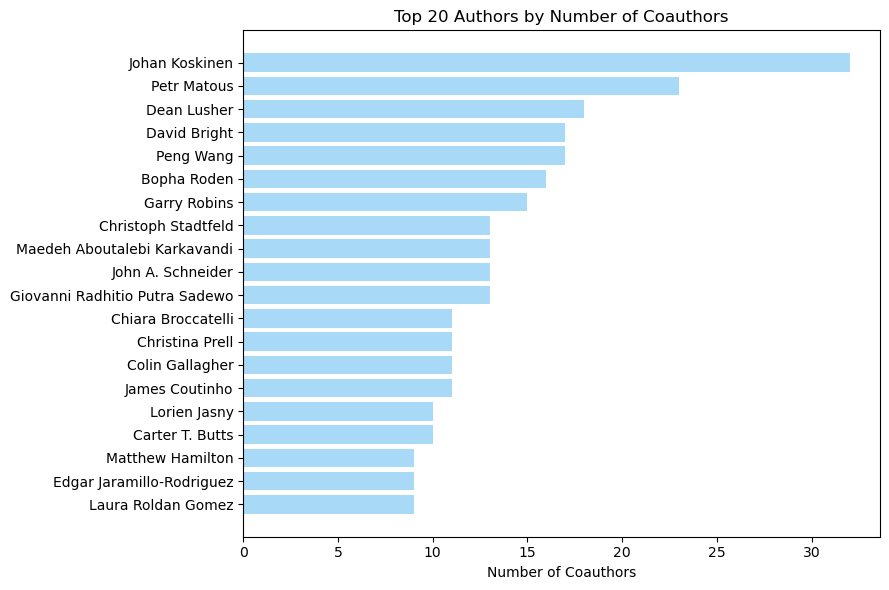

In [17]:
#Draw bar chart to display top 20 authors with most coauthors
plt.figure(figsize=(9,6))
plt.barh(coauthor20["Author"], coauthor20["Num_Coauthors"], color="#A8D9F6")
plt.gca().invert_yaxis()
plt.xlabel("Number of Coauthors")
plt.title("Top 20 Authors by Number of Coauthors")
plt.tight_layout()
plt.show()


In [18]:
#Split the author column and expand into multiple lines
authors_spl = research.copy()
authors_spl["Authors"] = authors_spl["Authors"].str.split(",")
authors_spl = authors_spl.explode("Authors")

# Remove space
authors_spl["Authors"] = authors_spl["Authors"].str.strip()
authors_spl

,Volume,Date,Article,Authors,Article_URL,Type,Keywords,page,date
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,Jennifer Watling Neal,https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-...",In progress,2026-01
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,Zachary P. Neal,https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,Emily Kruidhof,https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,Rense Corten,https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,Lea Ellwardt,https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
...,...,...,...,...,...,...,...,...,...
391,Volume 63,Pages 1-230 (October 2020),Modeling the dynamism of HIV information diffu...,Lindsay E. Young,https://www.sciencedirect.com/science/article/...,Research article,NaN,Pages 1-230,2020-10
391,Volume 63,Pages 1-230 (October 2020),Modeling the dynamism of HIV information diffu...,Jerome Mayaud,https://www.sciencedirect.com/science/article/...,Research article,NaN,Pages 1-230,2020-10
391,Volume 63,Pages 1-230 (October 2020),Modeling the dynamism of HIV information diffu...,Sze-Chuan Suen,https://www.sciencedirect.com/science/article/...,Research article,NaN,Pages 1-230,2020-10
391,Volume 63,Pages 1-230 (October 2020),Modeling the dynamism of HIV information diffu...,Milind Tambe,https://www.sciencedirect.com/science/article/...,Research article,NaN,Pages 1-230,2020-10


In [19]:
# Calculate the number of publications for each author
author_num = (
    authors_spl["Authors"]
    .value_counts()
    .reset_index()
)
author_num

,Authors,count
0,Johan Koskinen,9
1,Carter T. Butts,8
2,Petr Matous,6
3,David Bright,5
4,Zachary P. Neal,5
...,...,...
876,H. Eugene Stanley,1
877,Kate Vinita Fitch,1
878,jimi adams,1
879,Christian S. Schmid,1


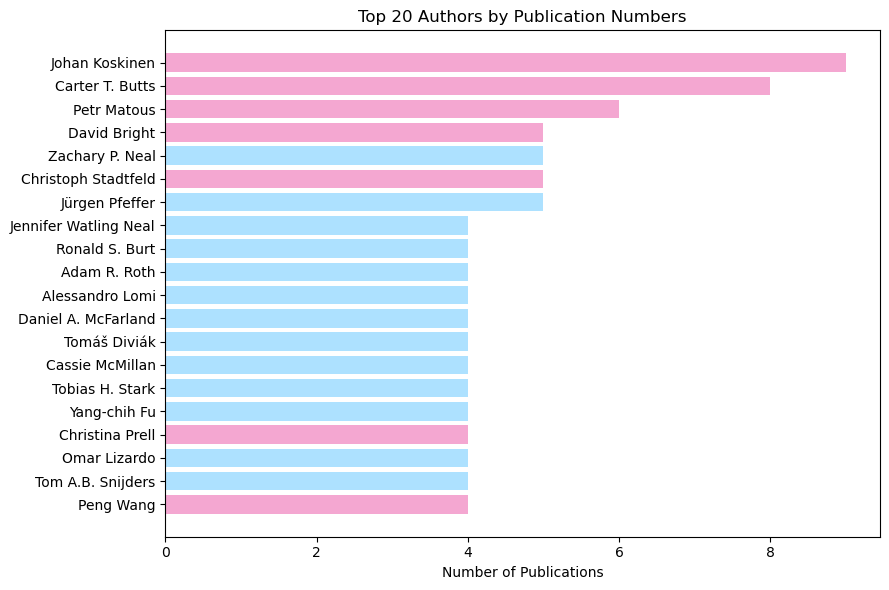

In [20]:
#Draw bar chart to display the top 20 authors
# Extract top 20 authors by number of publications
authors_20 = author_num.head(20)

#Creat a list of the top 20 authors by number of collaborators 
coauthor20 = coauthor_count.head(20)["Author"].tolist()

# Mark as pink if the author is in the list of top20 coauthors
colors = [
    "#F4A7D1" if author in coauthor20 else "#ADE1FF"
    for author in authors_20["Authors"]
]

# Draw bar chart
plt.figure(figsize=(9,6))
plt.barh(authors_20["Authors"], authors_20["count"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Number of Publications")
plt.title("Top 20 Authors by Publication Numbers")
plt.tight_layout()
plt.show()

<font size = "4">

**Finding**

The coauthorship and productivity analysis highlights a small group of scholars who are both prolific and well connected. Authors with the highest publication counts, especially the top three, also maintain a considerable number of coauthors, which is intutive as sustained productivity accompanies extensive collaboration.

Johan Koskinen stands out as both the most collaborative and the most productive author. Also, Petr Matous and David Bright have high publication output and wide coauthorship networks, suggesting their central roles in connecting research teams and contribution to the field. 

For authors with fewer than five publications, they tend to have a relatively modest number of collaborators, indicating repeated partnerships or independent research patterns.
